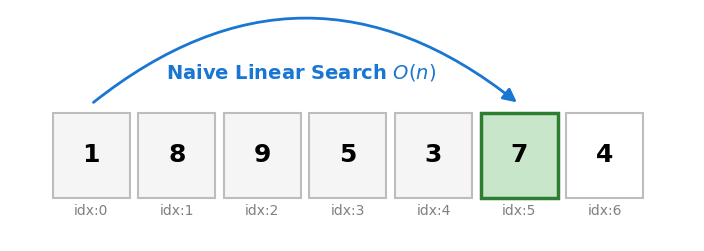

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

data = [1, 8, 9, 5, 3, 7, 4]
target_idx = 5

fig, ax = plt.subplots(figsize=(10, 3))

for i, val in enumerate(data):
    color = 'white'
    edgecolor = '#BDBDBD'
    linewidth = 1.5
    
    if i < target_idx:
        color = '#F5F5F5'  # Scanned
    elif i == target_idx:
        color = '#C8E6C9'  # Target (Found)
        edgecolor = '#2E7D32'
        linewidth = 2.5
    
    rect = patches.Rectangle((i, 0), 0.9, 1, facecolor=color, edgecolor=edgecolor, linewidth=linewidth)
    ax.add_patch(rect)
    ax.text(i + 0.45, 0.5, str(val), ha='center', va='center', fontsize=18, family='sans-serif', weight='bold')
    ax.text(i + 0.45, -0.15, f'idx:{i}', ha='center', va='center', fontsize=10, color='gray')

# Sequential sweep arrow
arrow = patches.FancyArrowPatch((0.45, 1.1), (5.45, 1.1),
                                connectionstyle="arc3,rad=-0.4",
                                arrowstyle='-|>', 
                                mutation_scale=20,
                                color='#1976D2', 
                                linewidth=2)
ax.add_patch(arrow)
ax.text(2.9, 1.4, 'Naive Linear Search $O(n)$', ha='center', color='#1976D2', fontsize=14, weight='bold')

ax.set_xlim(-0.5, 7.5)
ax.set_ylim(-0.5, 2.2)
ax.set_aspect('equal')
ax.axis('off')

plt.savefig('1d_unsorted.svg', format='svg', bbox_inches='tight', transparent=True)

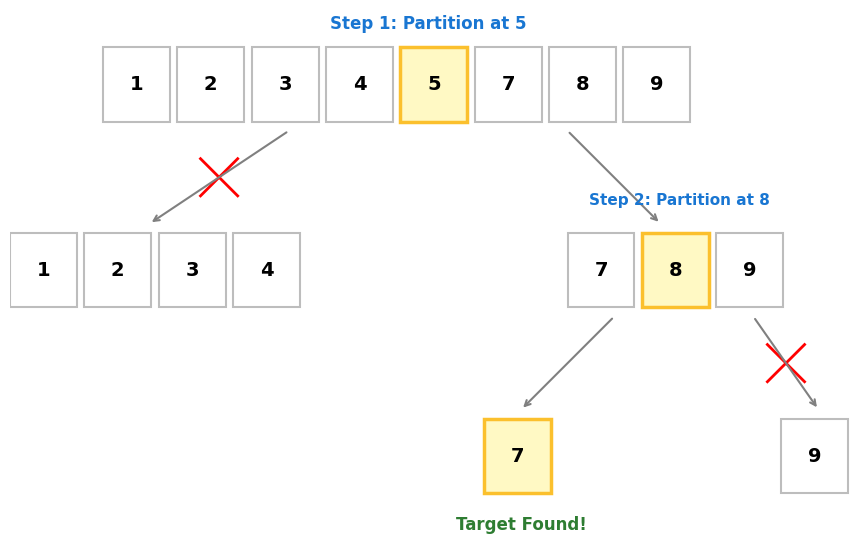

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_array(ax, data, x_start, y_center, box_size=0.8, highlight_idx=None):
    for i, val in enumerate(data):
        x = x_start + i * box_size
        y = y_center - box_size / 2
        
        color = 'white'
        edgecolor = '#BDBDBD'
        linewidth = 1.5
        
        if highlight_idx is not None and i == highlight_idx:
            color = '#FFF9C4'  # Light yellow for the pivot/partition element
            edgecolor = '#FBC02D'
            linewidth = 2.5
            
        rect = patches.Rectangle((x, y), box_size * 0.9, box_size, facecolor=color, edgecolor=edgecolor, linewidth=linewidth)
        ax.add_patch(rect)
        ax.text(x + box_size * 0.45, y_center, str(val), ha='center', va='center', fontsize=14, weight='bold')

def draw_crossed_arrow(ax, start, end):
    # Draw the arrow
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    # Draw a cross in the middle
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    size = 0.2
    ax.plot([mid_x - size, mid_x + size], [mid_y - size, mid_y + size], color='red', lw=2)
    ax.plot([mid_x - size, mid_x + size], [mid_y + size, mid_y - size], color='red', lw=2)

fig, ax = plt.subplots(figsize=(12, 7))

# Level 0: [1, 2, 3, 4, 5, 7, 8, 9]
# Pivot is 5 (idx 4)
root_data = [1, 2, 3, 4, 5, 7, 8, 9]
draw_array(ax, root_data, x_start=2.5, y_center=6, highlight_idx=4)
ax.text(6, 6.6, 'Step 1: Partition at 5', ha='center', fontsize=12, weight='bold', color='#1976D2')

# Arrows from Level 0 to Level 1
# Left goes to [1, 2, 3, 4] - Crossed
draw_crossed_arrow(ax, (4.5, 5.5), (3.0, 4.5))
# Right goes to [7, 8, 9]
ax.annotate('', xy=(8.5, 4.5), xytext=(7.5, 5.5), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Level 1 Left: [1, 2, 3, 4]
draw_array(ax, [1, 2, 3, 4], x_start=1.5, y_center=4)

# Level 1 Right: [7, 8, 9]
# Pivot is 8 (idx 1)
draw_array(ax, [7, 8, 9], x_start=7.5, y_center=4, highlight_idx=1)
ax.text(8.7, 4.7, 'Step 2: Partition at 8', ha='center', fontsize=11, weight='bold', color='#1976D2')

# Arrows from Level 1 Right to Level 2
# Left goes to [7]
ax.annotate('', xy=(7.0, 2.5), xytext=(8.0, 3.5), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
# Right goes to [9] - Crossed
draw_crossed_arrow(ax, (9.5, 3.5), (10.2, 2.5))

# Level 2: [7]
draw_array(ax, [7], x_start=6.6, y_center=2, highlight_idx=0)
ax.text(7.0, 1.2, 'Target Found!', ha='center', fontsize=12, color='#2E7D32', weight='bold')

# Add a block for [9] just to show the crossing
draw_array(ax, [9], x_start=9.8, y_center=2)

ax.set_xlim(1.5, 10.6)
ax.set_ylim(1, 6.8)
ax.set_aspect('equal')
ax.axis('off')

plt.savefig('1d_sorted_binary.svg', format='svg', bbox_inches='tight', transparent=True)

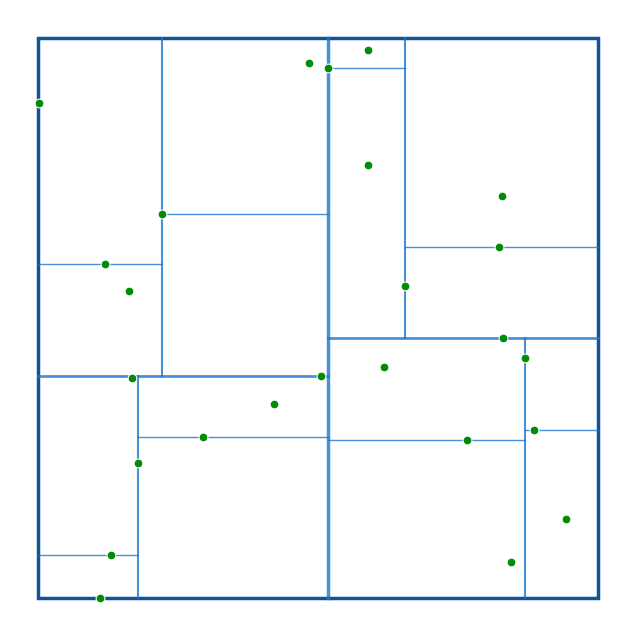

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
np.random.seed(23)
n_points = 25
points = np.random.rand(n_points, 2)

fig, ax = plt.subplots(figsize=(8, 8))

def draw_kd_tree(pts, x_min, x_max, y_min, y_max, depth):
    if len(pts) <= 2 or depth > 5:
        return

    # Alternate axis: 0 for x (vertical line), 1 for y (horizontal line)
    axis = depth % 2
    
    # Sort points along the chosen axis and find the median
    pts_sorted = pts[pts[:, axis].argsort()]
    median_idx = len(pts_sorted) // 2
    median_val = pts_sorted[median_idx, axis]
    
    # Draw the splitting line
    lw = max(0.5, 2.5 - depth * 0.5) # Thinner lines for deeper levels
    
    # Define a vibrant color for the splitting lines
    line_color = '#1976D2' # DeepSkyBlue, distinct and vibrant
    
    if axis == 0: # Vertical split
        ax.plot([median_val, median_val], [y_min, y_max], color=line_color, linewidth=lw, alpha=0.8)
        # Recurse
        draw_kd_tree(pts_sorted[:median_idx], x_min, median_val, y_min, y_max, depth + 1)
        draw_kd_tree(pts_sorted[median_idx:], median_val, x_max, y_min, y_max, depth + 1)
    else: # Horizontal split
        ax.plot([x_min, x_max], [median_val, median_val], color=line_color, linewidth=lw, alpha=0.8)
        # Recurse
        draw_kd_tree(pts_sorted[:median_idx], x_min, x_max, y_min, median_val, depth + 1)
        draw_kd_tree(pts_sorted[median_idx:], x_min, x_max, median_val, y_max, depth + 1)

# Plot the points
# Use a highly vibrant and contrasting color: HotPink
ax.scatter(points[:, 0], points[:, 1], c="#008c05", s=40, zorder=10, edgecolors='#ffffff', linewidths=0.75)

# Initial boundary
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, color="#115396", linewidth=2.5))

# Start recursion
draw_kd_tree(points, 0, 1, 0, 1, 0)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.axis('off')

# Save as vibrant version
plt.savefig('kd_tree_partitioning.svg', format='svg', bbox_inches='tight', transparent=True)